In [2]:
# ==========================================
# Step 1 : Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("C:/Users/Administrator/Downloads/Salary Data.csv")

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
df.shape

(375, 6)

In [7]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [8]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [9]:
# Remove rows with missing values
df = df.dropna()

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(49)

In [12]:
# ==========================================
# Step 15 : Remove Duplicate Rows
# ==========================================

df = df.drop_duplicates()

In [13]:
df.shape

(324, 6)

In [14]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


Age
[32. 28. 45. 36. 52. 29. 42. 31. 26. 38. 48. 35. 40. 27. 44. 33. 39. 25.
 51. 34. 47. 30. 41. 37. 24. 43. 50. 46. 49. 23. 53.]

Gender
['Male' 'Female']

Education Level
["Bachelor's" "Master's" 'PhD']

Job Title
['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'HR Generalist'
 'Project Engineer' 'Customer Success Rep' 'Sales Executive' 'UX Designer'
 'Operations Director' 'Network Engineer' 'Admini

In [15]:
# ==========================================
# Step 19 : Check Number of Unique Values
# ==========================================

for col in df.columns:
    print(col, ":", df[col].nunique())

Age : 31
Gender : 2
Education Level : 3
Job Title : 174
Years of Experience : 28
Salary : 36


In [16]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


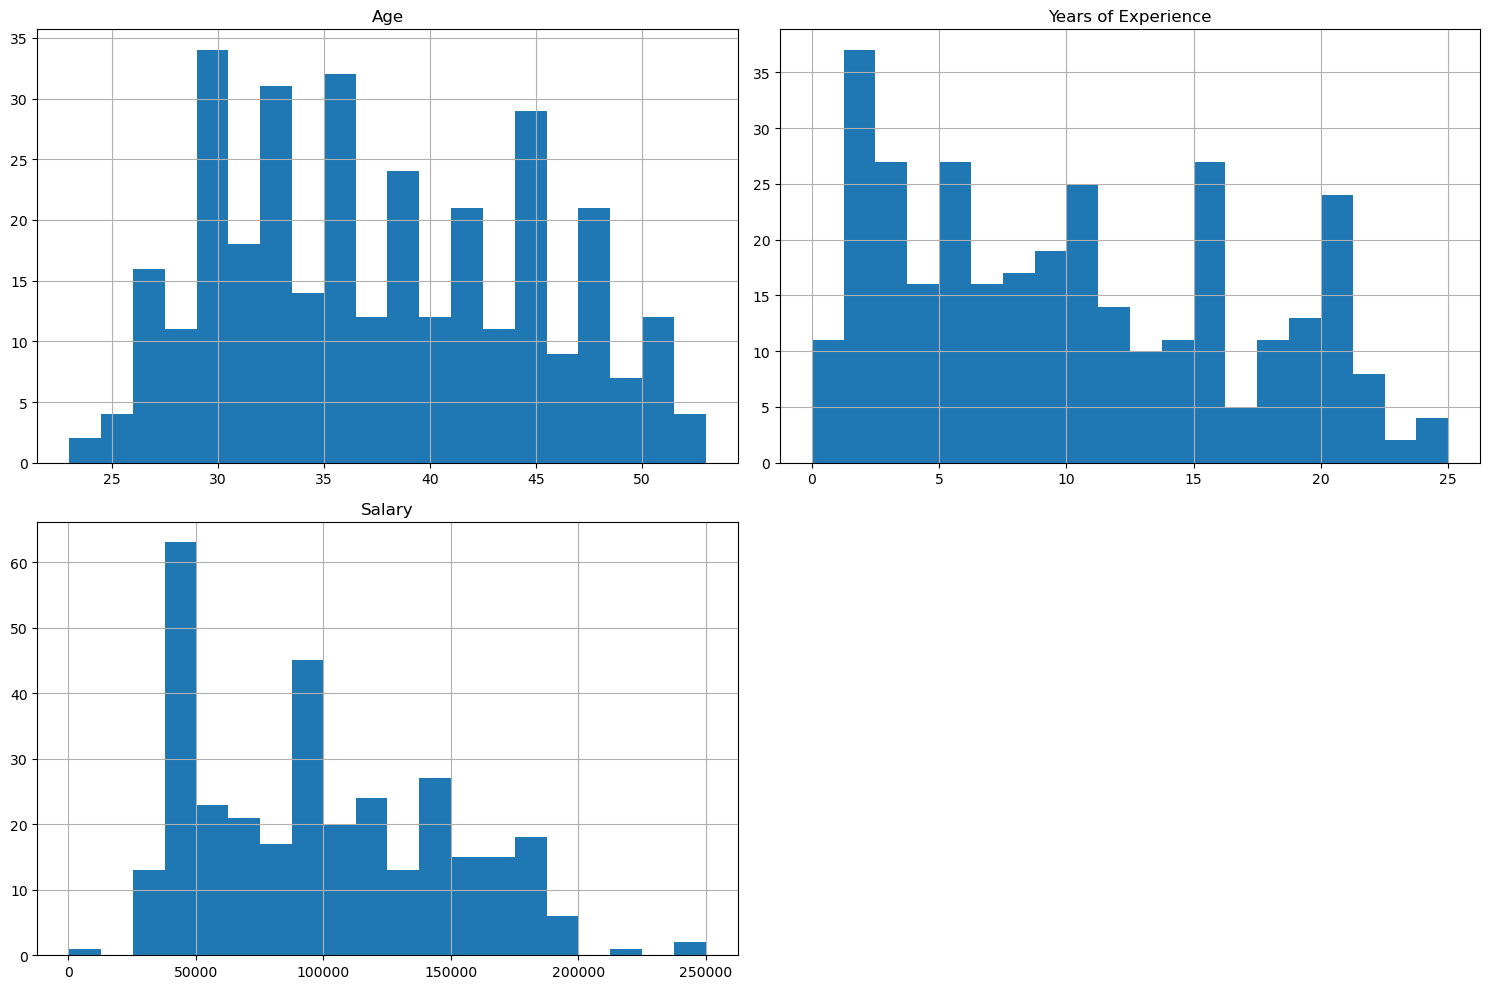

In [17]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [18]:
df.select_dtypes(include=np.number).columns

Index(['Age', 'Years of Experience', 'Salary'], dtype='object')

In [19]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

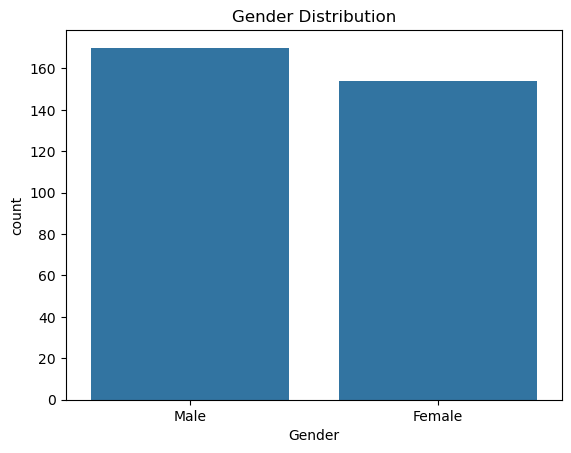

In [20]:
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()

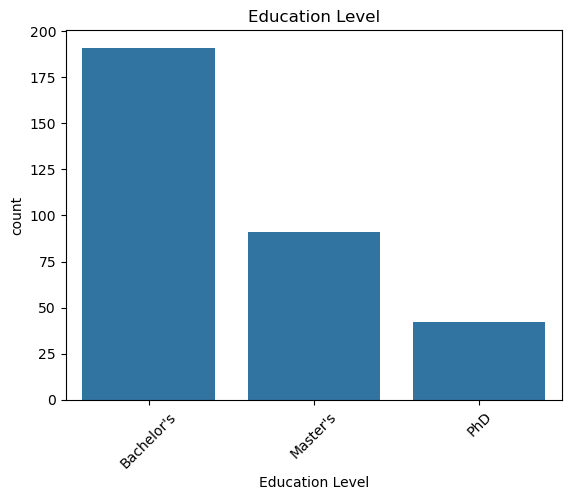

In [21]:
sns.countplot(x="Education Level", data=df)

plt.xticks(rotation=45)
plt.title("Education Level")
plt.show()

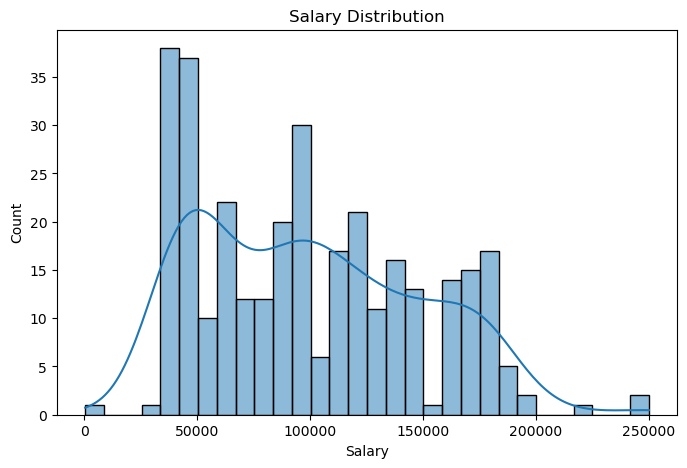

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.show()

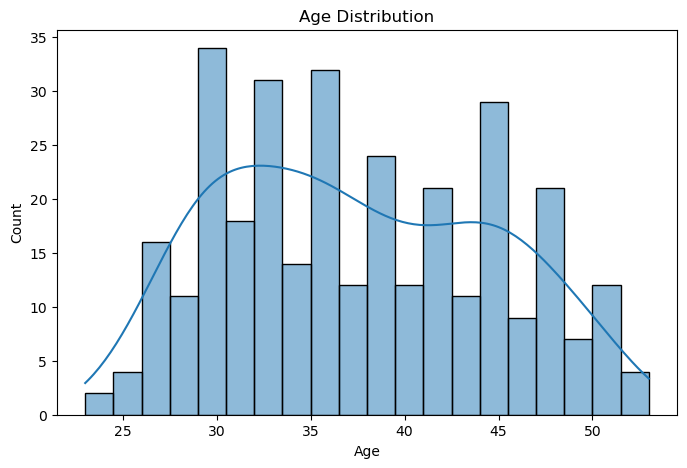

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

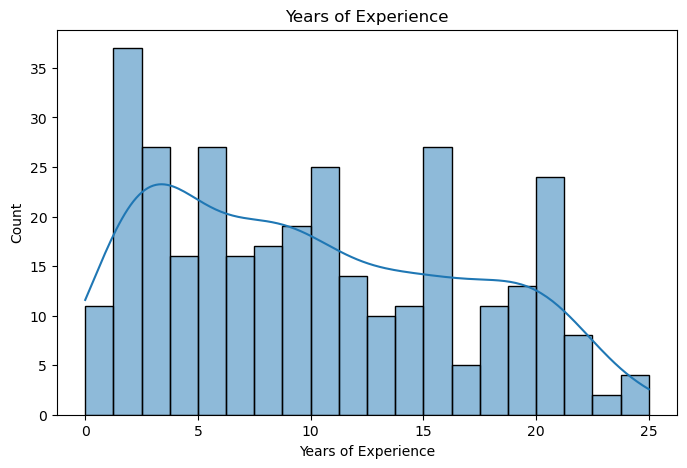

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Years of Experience"], bins=20, kde=True)

plt.title("Years of Experience")

plt.show()

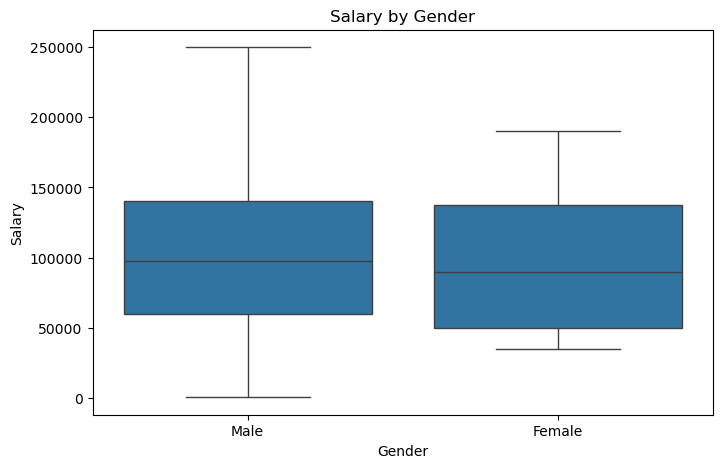

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Gender", y="Salary", data=df)

plt.title("Salary by Gender")

plt.show()

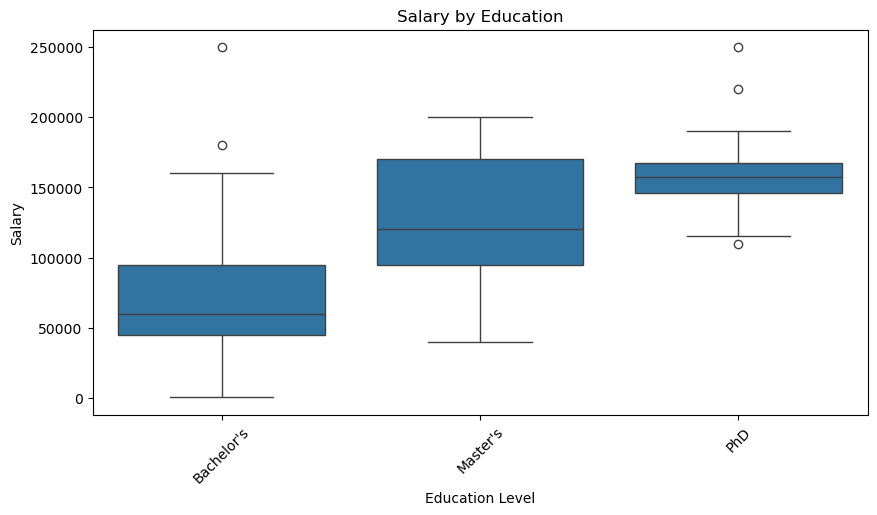

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Education Level", y="Salary", data=df)

plt.xticks(rotation=45)

plt.title("Salary by Education")

plt.show()

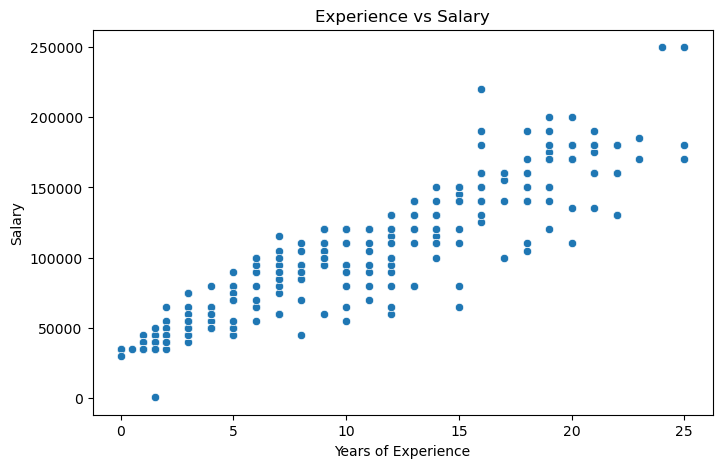

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Years of Experience", y="Salary", data=df)

plt.title("Experience vs Salary")

plt.show()

In [28]:
correlation = df.corr(numeric_only=True)

correlation

,Age,Years of Experience,Salary
Age,1.000000,0.979192,0.916543
Years of Experience,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


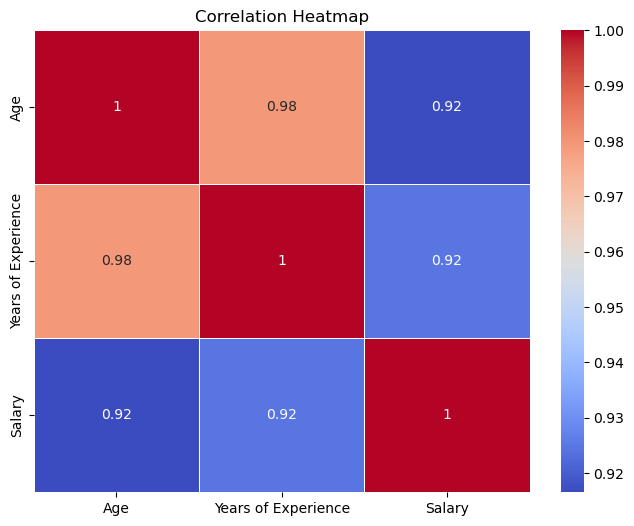

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
df.groupby("Education Level")["Salary"].mean()

Education Level
Bachelor's     73902.356021
Master's      127912.087912
PhD           158095.238095
Name: Salary, dtype: float64

In [31]:
df.groupby("Gender")["Salary"].mean()

Gender
Female     96136.363636
Male      103472.647059
Name: Salary, dtype: float64

In [32]:
df.groupby("Job Title")["Salary"].mean().sort_values(ascending=False)

Job Title
CEO                                   250000.0
Chief Technology Officer              250000.0
Chief Data Officer                    220000.0
Director                              200000.0
VP of Finance                         200000.0
                                        ...   
Help Desk Analyst                      35000.0
Data Entry Clerk                       35000.0
Junior Customer Support Specialist     35000.0
Sales Representative                   30000.0
Junior Business Operations Analyst     17675.0
Name: Salary, Length: 174, dtype: float64

In [33]:
df.groupby("Job Title")["Years of Experience"].mean()

Job Title
Account Manager                  5.0
Accountant                       4.0
Administrative Assistant         9.0
Business Analyst                 6.0
Business Development Manager     8.0
                                ... 
UX Designer                      5.0
UX Researcher                    2.0
VP of Finance                   19.0
VP of Operations                19.0
Web Developer                    6.0
Name: Years of Experience, Length: 174, dtype: float64

In [34]:
df["Salary"].max()

250000.0

In [35]:
df["Salary"].min()

350.0

In [36]:
df["Salary"].mean()

np.float64(99985.64814814815)

In [37]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Age', 'Years of Experience', 'Salary'], dtype='object')

Categorical Columns:
Index(['Gender', 'Education Level', 'Job Title'], dtype='object')


In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

In [39]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [40]:
df.corr

<bound method DataFrame.corr of       Age  Gender  Education Level  Job Title  Years of Experience    Salary
0    32.0       1                0        159                  5.0   90000.0
1    28.0       0                1         17                  3.0   65000.0
2    45.0       1                2        130                 15.0  150000.0
3    36.0       0                0        101                  7.0   60000.0
4    52.0       1                1         22                 20.0  200000.0
..    ...     ...              ...        ...                  ...       ...
348  28.0       0                0         68                  1.0   35000.0
349  36.0       1                0        111                  8.0  110000.0
350  44.0       0                2        115                 16.0  160000.0
351  31.0       1                0         63                  3.0   55000.0
371  43.0       1                1         30                 19.0  170000.0

[324 rows x 6 columns]>

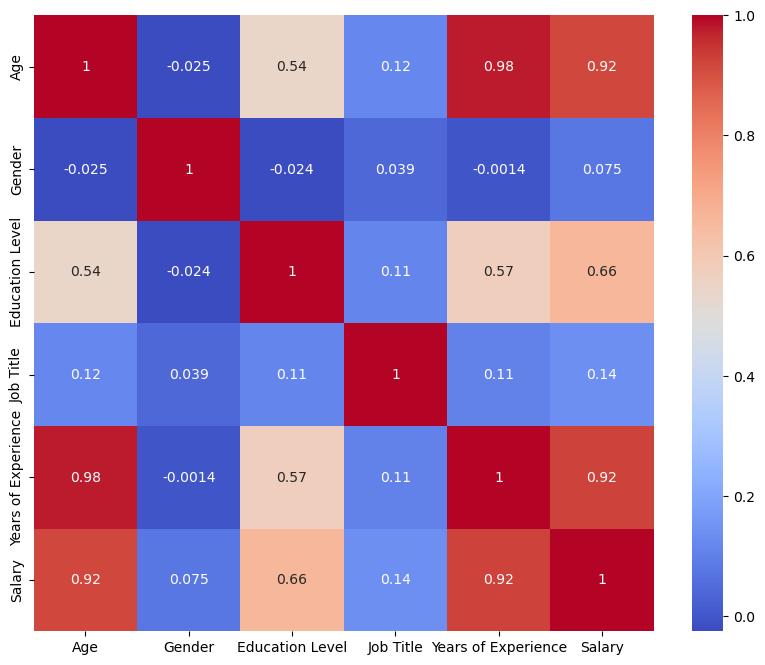

In [41]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [43]:
x = df.drop("Salary",axis=1)
y = df["Salary"]

In [46]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
print("X_train :", x_train.shape)

print("X_test :", x_test.shape)

print("y_train :", y_train.shape)

print("y_test :", y_test.shape)

X_train : (259, 5)
X_test : (65, 5)
y_train : (259,)
y_test : (65,)


In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
model.intercept_

np.float64(-48243.49422999601)

In [52]:
model.coef_

array([ 2812.90696248,  7389.07833506, 15422.73585954,    19.57695617,
        2892.12850555])

In [54]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Age,2812.906962
1,Gender,7389.078335
2,Education Level,15422.735860
3,Job Title,19.576956
4,Years of Experience,2892.128506


In [55]:
y_pred = model.predict(x_test)
print(y_pred)

[117415.91344602 125562.80742758  48965.15386167 128739.34887988
 106828.49930535  99654.76748821  49101.27883652  57130.71108104
 166333.69009266  43112.61060113  40544.18249367 122553.217185
 107631.15450848 155580.48335296  83652.23602446 170890.28450906
  98984.50106226 109338.33008328  42267.86835535  48089.87647812
  75674.93528581  64499.29874156  63619.2494321   31543.41552147
 188376.92844437  90340.76921722 155285.91529198 160863.57809872
 185183.73163709  34741.26224478 124850.6230462  165106.94121635
  87085.00622186 155425.69514031 149190.25441885  45729.74800187
  88475.39474629  92025.62668073  97997.32557607  40411.112659
  89995.79796521  53873.21977084 108677.48549927  54590.96778663
  36497.92729223  48611.85493217 129193.72126941  43102.58902589
 162383.16672117  81874.95829259 157771.0301154   43984.89040816
  59950.21740617  94023.81456492  84929.3880918   60296.00325465
  91816.87952546  56177.1258728   75243.32853162 104701.69952733
 117279.78847117  83396.82187

In [56]:
comparison = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
132,100000.0,117415.913446
108,100000.0,125562.807428
137,50000.0,48965.153862
9,110000.0,128739.348880
181,105000.0,106828.499305
...,...,...
104,80000.0,117279.788471
233,85000.0,83396.821876
60,170000.0,177743.761029
94,75000.0,72275.144274


In [58]:
sample_employee = x_test.iloc[[0]]

predicted_salary = model.predict(sample_employee)

predicted_salary

array([117415.91344602])

In [60]:
sample_employee

,Age,Gender,Education Level,Job Title,Years of Experience
132,40.0,0,1,154,12.0


In [61]:
y_test.iloc[0]

np.float64(100000.0)

In [62]:
predicted_salary[0]

np.float64(117415.91344601712)

In [64]:
model.score(x_train, y_train)

0.8948422167138826

In [65]:
model.score(x_test, y_test)

0.8911231066517085

In [66]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [67]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 10570.786401136196


In [68]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 205754135.7172618


In [69]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error :", rmse)

Root Mean Squared Error : 14344.132449097846


In [70]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.8911231066517085


In [71]:
print("Model Evaluation")

print("---------------------------")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

Model Evaluation
---------------------------
MAE : 10570.786401136196
MSE : 205754135.7172618
RMSE : 14344.132449097846
R2 Score : 0.8911231066517085


In [72]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,1.057079e+04
1,MSE,2.057541e+08
2,RMSE,1.434413e+04
3,R2 Score,8.911231e-01


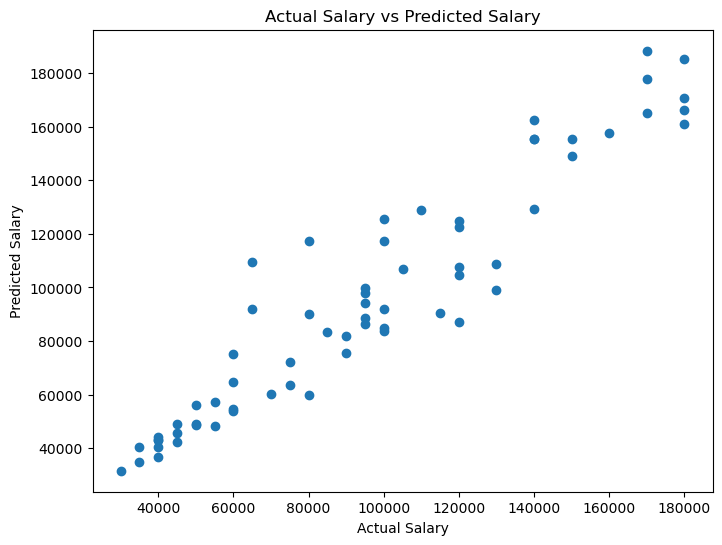

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual Salary vs Predicted Salary")

plt.show()

In [78]:
print(x.columns)

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')


In [79]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Gender": [1],
    "Education Level": [2],
     "Job Title": [3],
    "Years of Experience": [5],
})



In [80]:
predicted_salary = model.predict(new_employee)

In [82]:
print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 88897.63809474952
